# Exercise 4 — Dimensionality Reduction

## Part A — Why Do We Need Dimensionality Reduction?

Real datasets often contain many features.

Example:
```
apartment:
- size
- number of rooms
- floor
- location score
- age
- distance to center
- noise level
- energy consumption
...
```

As the number of features increases:

* visualization becomes difficult
* models become slower
* features may become redundant
* noise increases
* overfitting becomes easier

This is related to: `the curse of dimensionality`

### Goal of Dimensionality Reduction

Reduce the number of features while preserving the important structure of the data.

### Main Idea

Instead of describing the data with many correlated features: `(size, rooms, floor, age, ...)` we create: `new compact features` called `principal components`.

If two features contain similar information: `size ↔ number of rooms` then we may not need both.

PCA tries to find:

* the main directions of variation
* the most informative axes

## Part B — Generate Correlated Data

In [1]:
import numpy as np
import matplotlib.pyplot as plt

from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

np.random.seed(42)

# Apartment example
n = 120

size = np.random.normal(70, 15, n)

rooms = size / 25 + np.random.normal(0, 0.35, n)

X = np.column_stack([size, rooms])

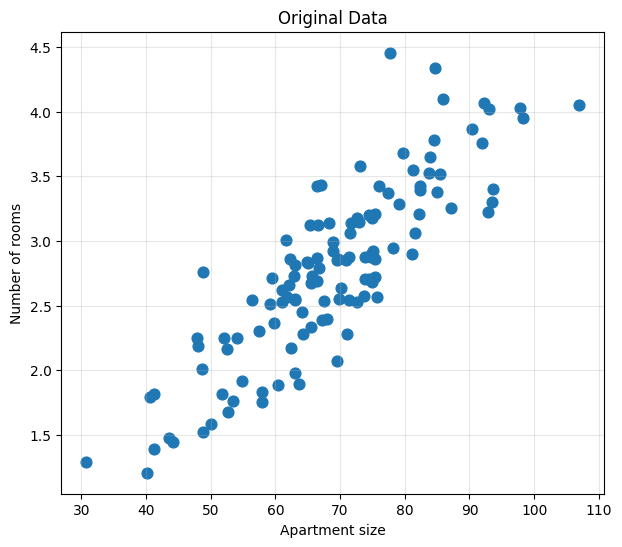

In [2]:
plt.figure(figsize=(7,6))

plt.scatter(X[:,0], X[:,1], s=60)

plt.xlabel("Apartment size")
plt.ylabel("Number of rooms")

plt.title("Original Data")

plt.grid(True, alpha=0.3)

plt.show()

### Questions

1. Are the features correlated?
    - Yes they are pretty correlated, we can draw a straight line to show this correlation.
2. Does the cloud follow a direction?
    - Yes, the direction is going upward and to the right. As size increases, number of rooms also increases.
3. Could one feature approximately predict the other?
    - Yes, if the correaltion between them is strong enough such that we can make a prediction.

## Part C — Apply PCA

Standardize the data. Why do we need to do this?

Data standardization is the process of scaling variables so they have a mean of 0 and a standard deviation 1. It is a mandatory first step in PCA to prevent features with larger units or magnitudes from disproportionately dominating the analysis.

In [3]:
scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

### Run PCA

In [13]:
pca = PCA(n_components=2)

X_pca = pca.fit_transform(X_scaled)

### Explained Variance

In [7]:
print("Explained variance ratio:")
print(pca.explained_variance_ratio_)
print(pca.explained_variance_ratio_[0])
print(pca.explained_variance_ratio_[1])

Explained variance ratio:
[0.92920937 0.07079063]
0.9292093716287498
0.07079062837125025


`PC1 = direction with maximum variance`

PCA tries to find the direction where the data spreads the most.
- PC1 explains ~92.9% of the total variance in the data
- PC2 explains ~7.1% of the total variance
- Together they explain 100% (since there are only 2 original features)

### Visualize PCA Directions

PCA components:
[[ 0.70710678  0.70710678]
 [-0.70710678  0.70710678]]
PC1: [0.70710678 0.70710678]
PC2: [-0.70710678  0.70710678]


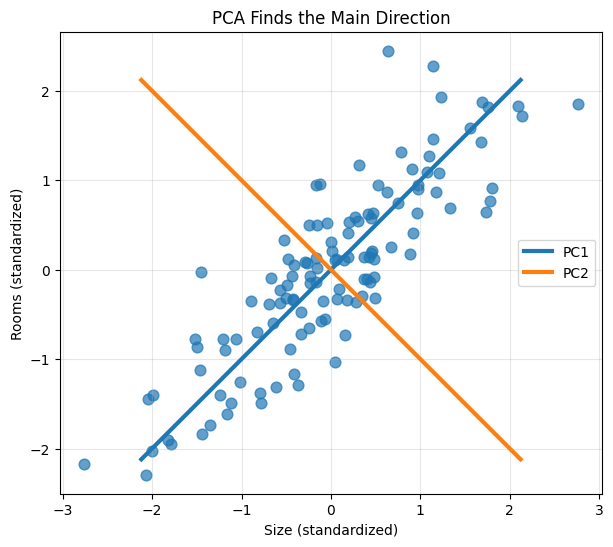

In [14]:
mean = X_scaled.mean(axis=0)

print("PCA components:")
print(pca.components_)

pc1 = pca.components_[0]
print("PC1:", pc1)

pc2 = pca.components_[1]
print("PC2:", pc2)

t = np.linspace(-3, 3, 100)

pc1_line = mean + t[:, None] * pc1
pc2_line = mean + t[:, None] * pc2

plt.figure(figsize=(7,6))

plt.scatter(
    X_scaled[:,0],
    X_scaled[:,1],
    s=60,
    alpha=0.7
)

plt.plot(
    pc1_line[:,0],
    pc1_line[:,1],
    linewidth=3,
    label="PC1"
)

plt.plot(              
    pc2_line[:,0],
    pc2_line[:,1],
    linewidth=3,
    label="PC2"
)

plt.xlabel("Size (standardized)")
plt.ylabel("Rooms (standardized)")

plt.title("PCA Finds the Main Direction")

plt.legend()

plt.grid(True, alpha=0.3)

plt.axis("equal")

plt.show()

### Questions

1. Why does PCA choose this direction?
    - PC1 is the direction where data points spread out the most, so we can project them onto the new single axis of this direction without losing so much information.
2. What does “maximum variance” mean visually?
    - Data points are spreading out the most along that direction.
3. Why is this direction informative?
    - Because it has maximum variance, it tells us the high positive correlation between the 2 features.

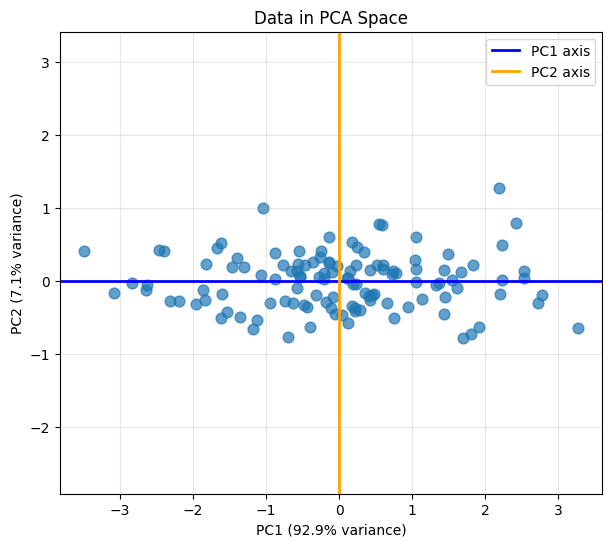

In [17]:
plt.figure(figsize=(7,6))
plt.scatter(
    X_pca[:,0],
    X_pca[:,1],
    s=60,
    alpha=0.7
)

plt.axhline(0, color='blue', linewidth=2, label='PC1 axis')
plt.axvline(0, color='orange', linewidth=2, label='PC2 axis')

plt.xlabel("PC1 (92.9% variance)")
plt.ylabel("PC2 (7.1% variance)")
plt.title("Data in PCA Space")
plt.legend()
plt.grid(True, alpha=0.3)
plt.axis("equal")
plt.show()

## Part D — Reduce to One Dimension

In [18]:
pca_1d = PCA(n_components=1)

X_reduced = pca_1d.fit_transform(X_scaled)

print(X_reduced.shape)

(120, 1)


### Before vs After PCA

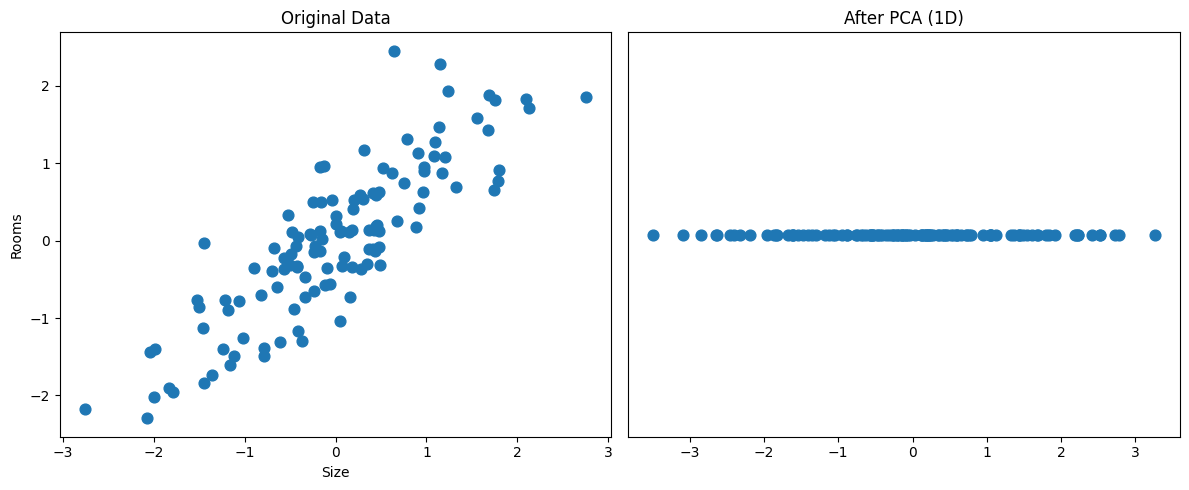

In [19]:
fig, axes = plt.subplots(1, 2, figsize=(12,5))

# Original
axes[0].scatter(
    X_scaled[:,0],
    X_scaled[:,1],
    s=60
)

axes[0].set_title("Original Data")
axes[0].set_xlabel("Size")
axes[0].set_ylabel("Rooms")

# Reduced
axes[1].scatter(
    X_reduced[:,0],
    np.zeros_like(X_reduced[:,0]),
    s=60
)

axes[1].set_title("After PCA (1D)")
axes[1].set_yticks([])

plt.tight_layout()

plt.show()

Even after reducing dimensions: `similar apartments stay close together`

PCA compresses the data while preserving important relationships.

## Part E — Real Dataset

Now apply PCA to a real dataset.

Choose one dataset from the table below.

| Dataset | Link | Features | What PCA can help with |
|---|---|---|---|
| Iris | [Open dataset](https://scikit-learn.org/stable/modules/generated/sklearn.datasets.load_iris.html) | flower measurements | visualize species in 2D |
| Wine | [Open dataset](https://scikit-learn.org/stable/modules/generated/sklearn.datasets.load_wine.html) | chemical properties | reduce many chemical features |
| Breast Cancer Wisconsin | [Open dataset](https://scikit-learn.org/stable/modules/generated/sklearn.datasets.load_breast_cancer.html) | tumor measurements | visualize benign vs malignant cases |
| Digits | [Open dataset](https://scikit-learn.org/stable/modules/generated/sklearn.datasets.load_digits.html) | image pixels | compress image features |
| Palmer Penguins | [Open dataset](https://github.com/allisonhorst/palmerpenguins) | biological measurements | visualize species groups |
| Wine Quality | [Open dataset](https://archive.ics.uci.edu/dataset/186/wine+quality) | chemical properties | reduce correlated wine features |

In [24]:
from sklearn.datasets import load_digits

digits = load_digits()

X = digits.data
y = digits.target

In [28]:
digits.feature_names

['pixel_0_0',
 'pixel_0_1',
 'pixel_0_2',
 'pixel_0_3',
 'pixel_0_4',
 'pixel_0_5',
 'pixel_0_6',
 'pixel_0_7',
 'pixel_1_0',
 'pixel_1_1',
 'pixel_1_2',
 'pixel_1_3',
 'pixel_1_4',
 'pixel_1_5',
 'pixel_1_6',
 'pixel_1_7',
 'pixel_2_0',
 'pixel_2_1',
 'pixel_2_2',
 'pixel_2_3',
 'pixel_2_4',
 'pixel_2_5',
 'pixel_2_6',
 'pixel_2_7',
 'pixel_3_0',
 'pixel_3_1',
 'pixel_3_2',
 'pixel_3_3',
 'pixel_3_4',
 'pixel_3_5',
 'pixel_3_6',
 'pixel_3_7',
 'pixel_4_0',
 'pixel_4_1',
 'pixel_4_2',
 'pixel_4_3',
 'pixel_4_4',
 'pixel_4_5',
 'pixel_4_6',
 'pixel_4_7',
 'pixel_5_0',
 'pixel_5_1',
 'pixel_5_2',
 'pixel_5_3',
 'pixel_5_4',
 'pixel_5_5',
 'pixel_5_6',
 'pixel_5_7',
 'pixel_6_0',
 'pixel_6_1',
 'pixel_6_2',
 'pixel_6_3',
 'pixel_6_4',
 'pixel_6_5',
 'pixel_6_6',
 'pixel_6_7',
 'pixel_7_0',
 'pixel_7_1',
 'pixel_7_2',
 'pixel_7_3',
 'pixel_7_4',
 'pixel_7_5',
 'pixel_7_6',
 'pixel_7_7']

### Apply PCA to 2D

In [21]:
scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

pca = PCA(n_components=2)

X_pca = pca.fit_transform(X_scaled)

### Visualize Reduced Data

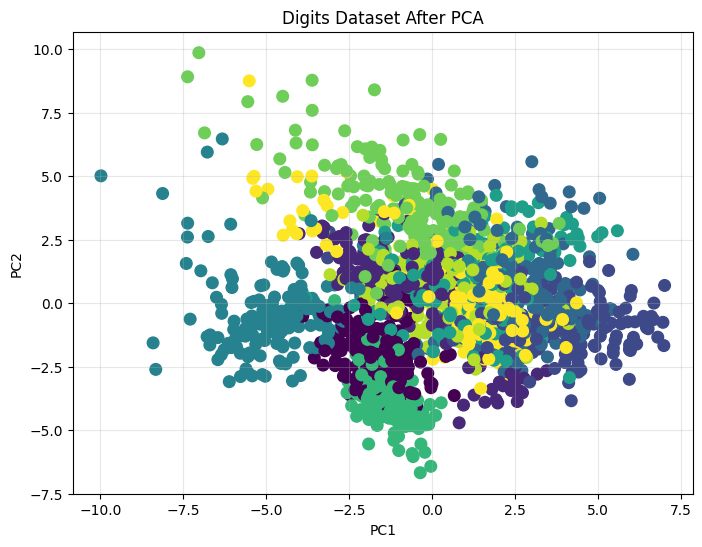

In [22]:
plt.figure(figsize=(8,6))

scatter = plt.scatter(
    X_pca[:,0],
    X_pca[:,1],
    c=y,
    s=70
)

plt.xlabel("PC1")
plt.ylabel("PC2")

plt.title("Digits Dataset After PCA")

plt.grid(True, alpha=0.3)

plt.show()

### Questions

1. Do the classes separate well?
    - The classes are not separate well, they heavily overlap in the center of the plot.
2. Which species overlap?
    - Almost every one of them.
3. Why is PCA useful for visualization?
    - Because real datasets have a lot of features, and humans can only see in 2D or 3D. PCA lets us compress all those dimensions down to just PC1 and PC2 — the two directions that preserve the most variance, and plot them. Even if the result isn't perfectly clean, it's the best possible 2D representation of a high-dimensional dataset.
5. Why can PCA help machine learning models?
    - It helps remove redundancy, speed up model training with less features espescially in very large datasets.

## Part F — Train a Model with Logistic Regression and PCA


Look in the previous exercises and find how to load a dataset, separate it in train/dev/test or just train/dev datasets. 

1. Use [LogisticRegression](https://scikit-learn.org/stable/modules/generated/sklearn.linear_model.LogisticRegression.html) or [LinearRegression](https://scikit-learn.org/stable/modules/generated/sklearn.linear_model.LinearRegression.html) depending on the task to train and test a model. Please report accuracy, precision and recall.
2. Use then PCA to reduce the dimensionality of the data, and redo step 1. Report metrics and see the difference. Is there any?

In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from datasets import load_dataset

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    ConfusionMatrixDisplay,
    classification_report,
)

dataset = load_dataset("nateraw/lung-cancer", split="train")
df = dataset.to_pandas()
df.head()

['GENDER', 'AGE', 'SMOKING', 'YELLOW_FINGERS', 'ANXIETY', 'PEER_PRESSURE', 'CHRONIC DISEASE', 'FATIGUE ', 'ALLERGY ', 'WHEEZING', 'ALCOHOL CONSUMING', 'COUGHING', 'SHORTNESS OF BREATH', 'SWALLOWING DIFFICULTY', 'CHEST PAIN', 'LUNG_CANCER']


In [18]:
features = ['GENDER', 
            'AGE', 
            'SMOKING', 
            'YELLOW_FINGERS', 
            'ANXIETY', 
            'PEER_PRESSURE', 
            'CHRONIC DISEASE', 
            'FATIGUE ', 
            'ALLERGY ', 
            'WHEEZING', 
            'ALCOHOL CONSUMING', 
            'COUGHING', 
            'SHORTNESS OF BREATH', 'SWALLOWING DIFFICULTY', 'CHEST PAIN', 'LUNG_CANCER']
X = df[features]
y = df["LUNG_CANCER"]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.3,
    random_state=42,
    stratify=y
)

categorical_cols = ["GENDER"]
numerical_cols = [col for col in X.columns if col != "GENDER"]

preprocessor = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), numerical_cols),
        ("cat", OneHotEncoder(drop="first"), categorical_cols), 
    ]
)

log_reg = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("classifier", LogisticRegression(max_iter=1000))
    ]
)

log_reg.fit(X_train, y_train)

ValueError: could not convert string to float: 'YES'